In [24]:
import pandas as pd
import numpy as np

import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [25]:
df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\iot\archive (1)\train_test_network.csv")

df.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [26]:
df.shape

(211043, 44)

In [27]:
print("Total columns:", len(df.columns))
df.dtypes


Total columns: 44


src_ip                     object
src_port                    int64
dst_ip                     object
dst_port                    int64
proto                      object
service                    object
duration                  float64
src_bytes                   int64
dst_bytes                   int64
conn_state                 object
missed_bytes                int64
src_pkts                    int64
src_ip_bytes                int64
dst_pkts                    int64
dst_ip_bytes                int64
dns_query                  object
dns_qclass                  int64
dns_qtype                   int64
dns_rcode                   int64
dns_AA                     object
dns_RD                     object
dns_RA                     object
dns_rejected               object
ssl_version                object
ssl_cipher                 object
ssl_resumed                object
ssl_established            object
ssl_subject                object
ssl_issuer                 object
http_trans_dep

In [28]:
# Percentage of missing values per column
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)


src_ip                    0.0
src_port                  0.0
ssl_cipher                0.0
ssl_resumed               0.0
ssl_established           0.0
ssl_subject               0.0
ssl_issuer                0.0
http_trans_depth          0.0
http_method               0.0
http_uri                  0.0
http_version              0.0
http_request_body_len     0.0
http_response_body_len    0.0
http_status_code          0.0
http_user_agent           0.0
http_orig_mime_types      0.0
http_resp_mime_types      0.0
weird_name                0.0
weird_addl                0.0
weird_notice              0.0
label                     0.0
ssl_version               0.0
dns_rejected              0.0
dns_RA                    0.0
missed_bytes              0.0
dst_ip                    0.0
dst_port                  0.0
proto                     0.0
service                   0.0
duration                  0.0
src_bytes                 0.0
dst_bytes                 0.0
conn_state                0.0
src_pkts  

In [29]:
# Count number of unique values in each column
unique_counts = df.nunique().sort_values(ascending=False)
unique_counts


duration                  68570
src_port                  26628
src_ip_bytes               3648
dst_ip_bytes               3304
dst_bytes                  2338
src_bytes                  2199
dst_port                   2039
dst_ip                      753
dns_query                   726
missed_bytes                694
src_pkts                    274
dst_pkts                    203
http_uri                     86
http_response_body_len       75
src_ip                       51
http_user_agent              35
conn_state                   13
dns_qtype                    12
weird_name                   11
http_trans_depth             11
http_resp_mime_types         10
type                         10
service                       9
http_status_code              8
http_request_body_len         6
ssl_cipher                    6
ssl_subject                   6
ssl_issuer                    5
http_method                   4
ssl_version                   4
dns_rcode                     4
weird_ad

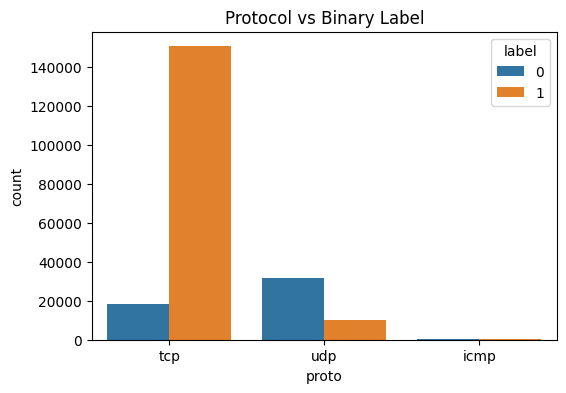

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='proto', hue='label', data=df)
plt.title("Protocol vs Binary Label")
plt.show()


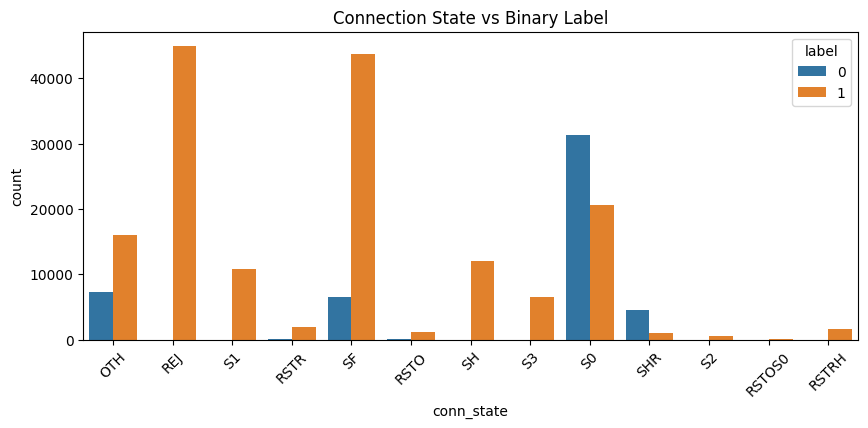

In [31]:
plt.figure(figsize=(10,4))
sns.countplot(x='conn_state', hue='label', data=df)
plt.xticks(rotation=45)
plt.title("Connection State vs Binary Label")
plt.show()


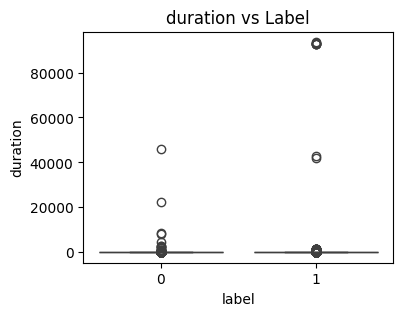

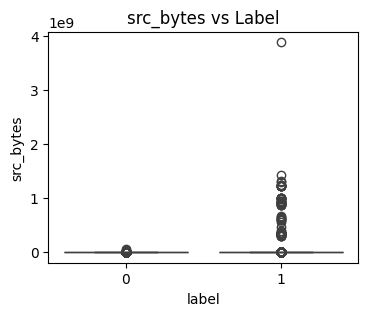

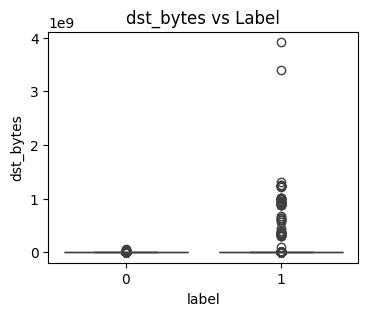

In [32]:
num_cols = ['duration', 'src_bytes', 'dst_bytes']

for col in num_cols:
    plt.figure(figsize=(4,3))
    sns.boxplot(x='label', y=col, data=df)
    plt.title(f"{col} vs Label")
    plt.show()


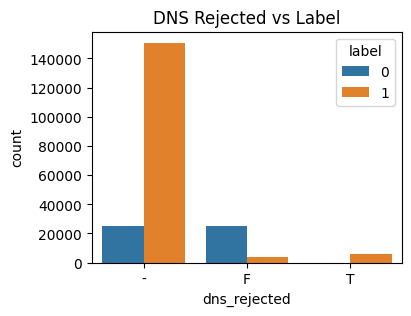

In [33]:
# DNS rejected vs label
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
sns.countplot(x='dns_rejected', hue='label', data=df)
plt.title("DNS Rejected vs Label")
plt.show()


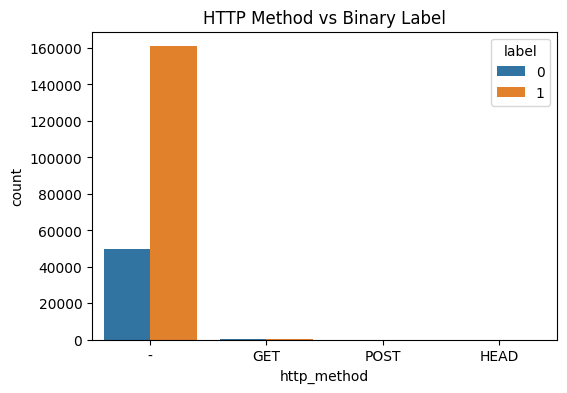

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x='http_method', hue='label', data=df)
plt.title("HTTP Method vs Binary Label")
plt.show()


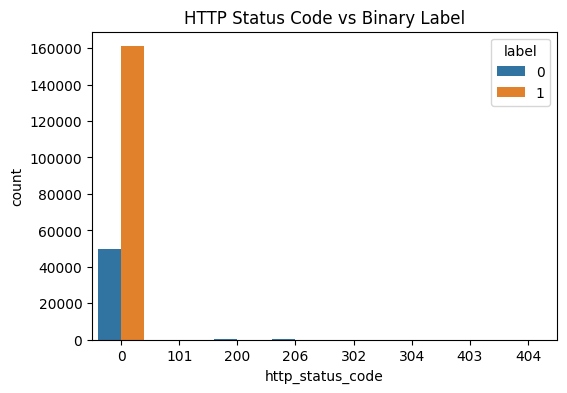

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='http_status_code', hue='label', data=df)
plt.title("HTTP Status Code vs Binary Label")
plt.show()


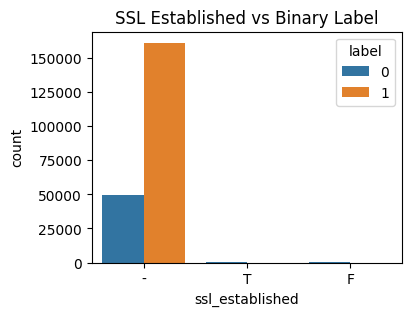

In [36]:
plt.figure(figsize=(4,3))
sns.countplot(x='ssl_established', hue='label', data=df)
plt.title("SSL Established vs Binary Label")
plt.show()


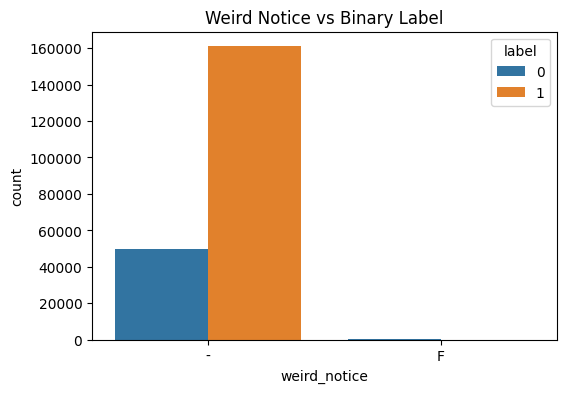

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='weird_notice', hue='label', data=df)
plt.title("Weird Notice vs Binary Label")
plt.show()


In [38]:
num_cols = [
    'duration', 'src_bytes', 'dst_bytes',
    'src_pkts', 'dst_pkts',
    'src_ip_bytes', 'dst_ip_bytes',
    'missed_bytes'
]

corr = df[num_cols + ['label']].corr()['label'].sort_values(ascending=False)
corr


label           1.000000
src_bytes       0.008344
dst_bytes       0.007698
duration        0.003665
missed_bytes    0.002734
dst_ip_bytes    0.000707
dst_pkts       -0.003170
src_ip_bytes   -0.010436
src_pkts       -0.102089
Name: label, dtype: float64

In [39]:
# Columns justified by EDA
keep_cols = [
    # core network semantics
    'proto',
    'service',
    'conn_state',

    # numeric behavior (to be transformed later)
    'duration',
    'src_bytes',
    'dst_bytes',
    'src_pkts',
    'dst_pkts',
    'missed_bytes',

    # DNS behavior
    'dns_rejected',

    # HTTP behavior
    'http_method',
    'http_status_code',

    # SSL behavior
    'ssl_established',

    # Weird / anomaly indicators
    'weird_notice',

    # labels
    'label',
    'type'
]

df_work = df[keep_cols].copy()

print("Working dataframe shape:", df_work.shape)
df_work.head()


Working dataframe shape: (211043, 16)


,proto,service,conn_state,duration,src_bytes,dst_bytes,src_pkts,dst_pkts,missed_bytes,dns_rejected,http_method,http_status_code,ssl_established,weird_notice,label,type
0,tcp,-,OTH,290.371539,101568,2592,108,31,0,-,-,0,-,-,1,backdoor
1,tcp,-,REJ,0.000102,0,0,1,1,0,-,-,0,-,-,1,backdoor
2,tcp,-,REJ,0.000148,0,0,1,1,0,-,-,0,-,-,1,backdoor
3,tcp,-,REJ,0.000113,0,0,1,1,0,-,-,0,-,-,1,backdoor
4,tcp,-,REJ,0.000130,0,0,1,1,0,-,-,0,-,-,1,backdoor
